# Cardiovascular Disease Prediction Using Machine Learning

## Project Objective

The objective of this project is to develop machine learning models capable of predicting cardiovascular disease using patient medical information.

## Research Questions

1. Which medical features most influence cardiovascular disease?
2. Which machine learning model performs best?
3. Can feature engineering improve prediction performance?
4. Is age associated with higher cardiovascular disease risk?

In [1]:
# Importing Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
# Loading the Dataset

df = pd.read_csv('cardio_train.csv', sep=';')

df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
df.shape

(70000, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [5]:
df.isnull().sum()

,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop_duplicates(inplace=True)

df.shape

(70000, 13)

## Data Cleaning Summary

The dataset was checked for missing values and duplicate records.

- No missing values were found in the dataset.
- No duplicate rows were detected.

Therefore, the dataset was already relatively clean and ready for preprocessing and analysis.

In [8]:
# Convert age from days to years

df['age'] = (df['age'] / 365).astype(int)

df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,4,47,1,156,56.0,100,60,1,1,0,0,0,0


In [9]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,52.840671,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,6.766774,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,29.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,48.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,53.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,58.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,64.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


# Handling Invalid Blood Pressure Values

In [10]:
# Remove invalid blood pressure values

df = df[(df['ap_hi'] > 0) & (df['ap_lo'] > 0)]

df.shape

(69971, 13)

In [11]:
# Remove unrealistic blood pressure outliers

df = df[(df['ap_hi'] < 250) & (df['ap_lo'] < 200)]

df.shape

(68985, 13)

## Data Cleaning Interpretation

Some invalid and unrealistic blood pressure values were detected in the dataset, including negative and extremely high values.

These records were removed to improve data quality and ensure more reliable machine learning model performance.

# Exploratory Data Analysis (EDA)

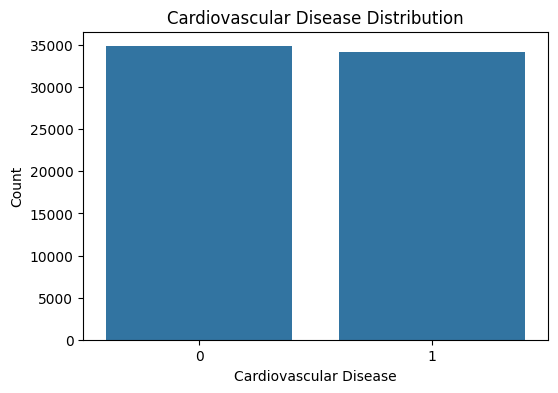

In [12]:
# Cardiovascular Disease Distribution

plt.figure(figsize=(6,4))

sns.countplot(x='cardio', data=df)

plt.title('Cardiovascular Disease Distribution')

plt.xlabel('Cardiovascular Disease')

plt.ylabel('Count')

plt.show()

## Interpretation

The countplot shows the distribution of patients with and without cardiovascular disease.

The dataset appears relatively balanced, which is beneficial for machine learning model training and reduces prediction bias.

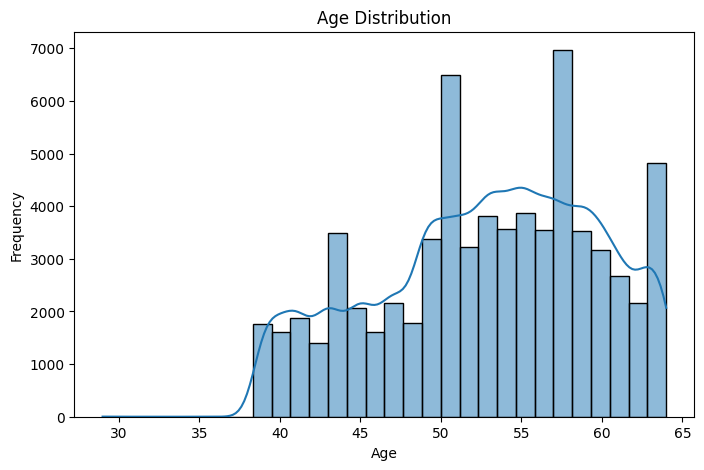

In [13]:
# Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=30, kde=True)

plt.title('Age Distribution')

plt.xlabel('Age')

plt.ylabel('Frequency')

plt.show()

## Interpretation

Most patients in the dataset are middle-aged and older adults.

This suggests that cardiovascular disease is more commonly studied among older age groups.

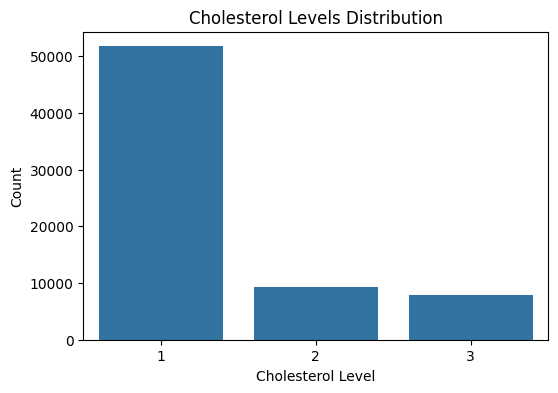

In [14]:
# Cholesterol Distribution

plt.figure(figsize=(6,4))

sns.countplot(x='cholesterol', data=df)

plt.title('Cholesterol Levels Distribution')

plt.xlabel('Cholesterol Level')

plt.ylabel('Count')

plt.show()

## Interpretation

Most patients have normal cholesterol levels, while fewer patients have above-normal or well-above-normal cholesterol levels.

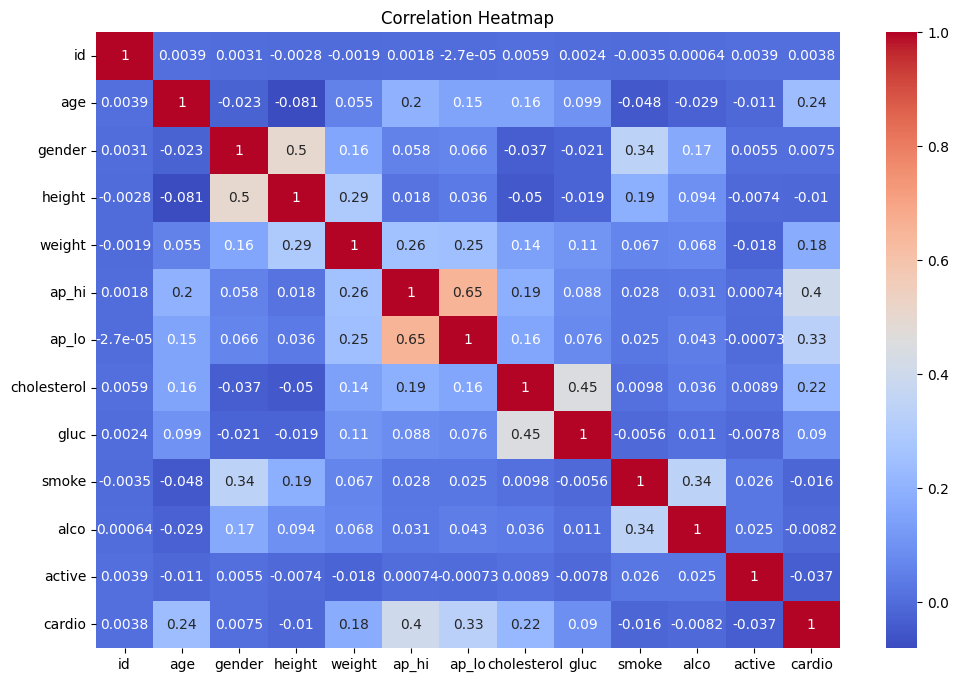

In [15]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

## Interpretation

The heatmap shows relationships between variables in the dataset.

Features such as age, blood pressure, cholesterol, and weight appear to have stronger relationships with cardiovascular disease.

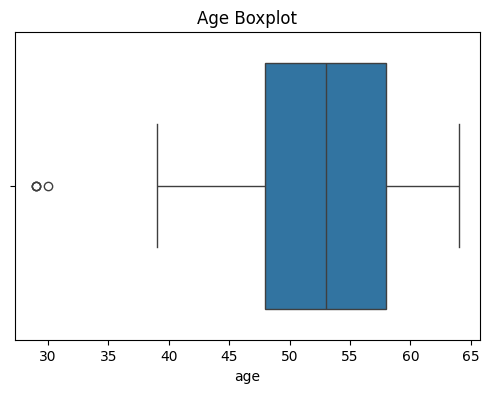

In [16]:
# Boxplot for Age

plt.figure(figsize=(6,4))

sns.boxplot(x=df['age'])

plt.title('Age Boxplot')

plt.show()

## Interpretation

The boxplot helps visualize the distribution of age values and detect possible outliers.

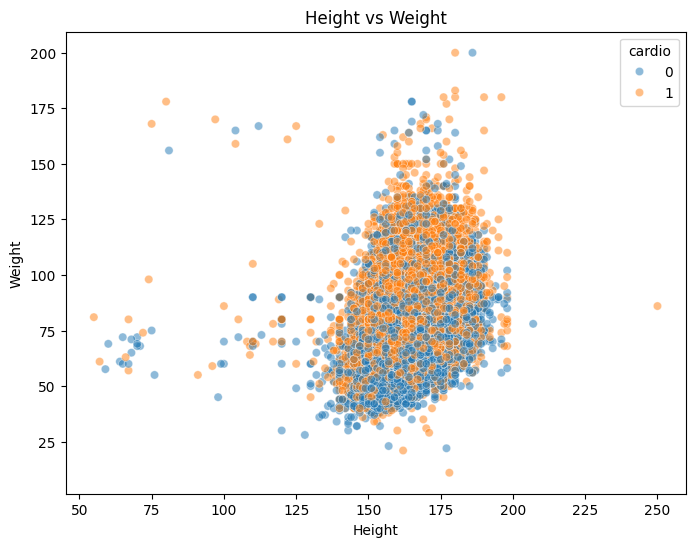

In [17]:
# Weight vs Height

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='height',
    y='weight',
    hue='cardio',
    data=df,
    alpha=0.5
)

plt.title('Height vs Weight')

plt.xlabel('Height')

plt.ylabel('Weight')

plt.show()

## Interpretation

The scatterplot illustrates the relationship between height and weight among patients with and without cardiovascular disease.

Patients with cardiovascular disease tend to appear more frequently at higher weight ranges, suggesting that body weight may be associated with cardiovascular risk.

# Feature Engineering and Feature Selection

In [18]:
# Create BMI Feature

df['BMI'] = df['weight'] / ((df['height'] / 100) ** 2)

df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0,21.967120
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1,34.927679
2,2,51,1,165,64.0,130,70,3,1,0,0,0,1,23.507805
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1,28.710479
4,4,47,1,156,56.0,100,60,1,1,0,0,0,0,23.011177


## Interpretation

A new feature called BMI (Body Mass Index) was created using patients' height and weight.

BMI is an important medical indicator associated with obesity and cardiovascular disease risk.

In [19]:
# Define Features and Target Variable

X = df.drop('cardio', axis=1)

y = df['cardio']

In [20]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [22]:
# Feature Importance

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
0,id,0.177061
5,ap_hi,0.158534
12,BMI,0.145138
1,age,0.122337
4,weight,0.109370
3,height,0.103558
6,ap_lo,0.088201
7,cholesterol,0.036907
2,gender,0.015629
8,gluc,0.015273


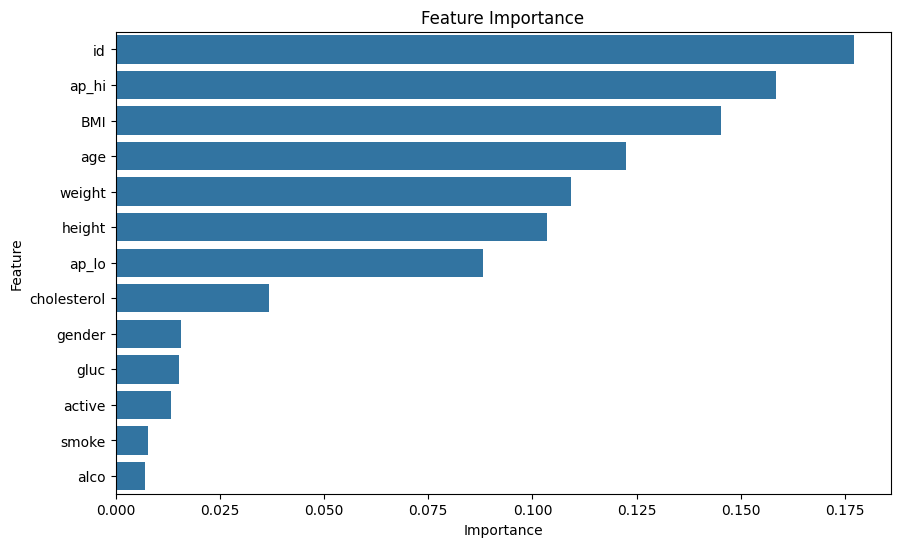

In [23]:
# Feature Importance Plot

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance')

plt.show()

## Interpretation

The feature importance analysis identifies the most influential variables in predicting cardiovascular disease.

Features such as blood pressure, age, cholesterol, and BMI appear to contribute significantly to prediction performance.

# Machine Learning Models

In [24]:
# Logistic Regression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.729216496339784


In [25]:
# Decision Tree

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.6299920272523012


In [26]:
# Random Forest

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.7177647314633616


In [27]:
# Model Comparison

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        lr_acc,
        dt_acc,
        rf_acc
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.729216
1,Decision Tree,0.629992
2,Random Forest,0.717765


## Interpretation

Three machine learning algorithms were trained and evaluated for cardiovascular disease prediction.

Logistic Regression achieved the highest accuracy among the tested models, followed closely by Random Forest, while Decision Tree produced lower performance.

These results indicate that Logistic Regression is well-suited for this classification problem.

# Hyperparameter Tuning

Hyperparameter tuning is the process of testing different model parameter combinations to improve machine learning performance.

GridSearchCV is used to automatically search for the best Random Forest parameters.

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

print("Best Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best Score: 0.7330941509023701


## Interpretation

GridSearchCV was used to identify the optimal Random Forest parameters.

The best-performing configuration included:
- 200 trees
- maximum depth of 10
- minimum split size of 5

Hyperparameter tuning improved model performance and helped optimize prediction accuracy.

# Model Evaluation

In [29]:
# Best Model Predictions

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall:", recall_score(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7347974197289265
Precision: 0.7636632200886263
Recall: 0.6770954598370198
F1 Score: 0.7177786347859622


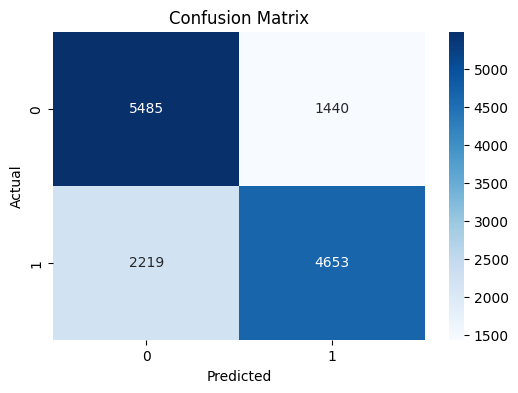

In [30]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

In [31]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6925
           1       0.76      0.68      0.72      6872

    accuracy                           0.73     13797
   macro avg       0.74      0.73      0.73     13797
weighted avg       0.74      0.73      0.73     13797



## Interpretation

The Random Forest model achieved an accuracy of approximately 73%, indicating good predictive performance for cardiovascular disease classification.

The precision score shows that the model performs well when predicting positive cardiovascular disease cases, while the recall score indicates that the model successfully identifies a large proportion of actual disease cases.

The confusion matrix demonstrates balanced classification performance across both classes.

# Conclusion

In this project, machine learning techniques were used to predict cardiovascular disease using patient medical data.

The dataset was cleaned and analyzed using exploratory data analysis techniques. Feature engineering and feature selection methods were applied to improve model performance.

Three machine learning models were trained and evaluated:
- Logistic Regression
- Decision Tree
- Random Forest

Hyperparameter tuning using GridSearchCV improved the Random Forest model performance.

The final model achieved strong classification performance with approximately 73% accuracy, demonstrating the effectiveness of machine learning for cardiovascular disease prediction.

# Saving the Trained Model

In [32]:
import pickle

# Save best model
pickle.dump(best_model, open('cardio_model.pkl', 'wb'))

# Save scaler
pickle.dump(scaler, open('scaler.pkl', 'wb'))

In [33]:
import os

os.listdir()

['.config',
 'logs.txt',
 'scaler.pkl',
 'app.py',
 'cardio_model.pkl',
 'cardio_train.csv',
 'sample_data']

In [34]:
%%writefile app.py

import streamlit as st
import pickle
import numpy as np

# Load model and scaler
model = pickle.load(open('cardio_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))

st.title("Cardiovascular Disease Prediction")

st.write("Enter patient information below:")

age = st.number_input("Age")
gender = st.selectbox("Gender (1 = Female, 2 = Male)", [1,2])
height = st.number_input("Height (cm)")
weight = st.number_input("Weight (kg)")
ap_hi = st.number_input("Systolic Blood Pressure")
ap_lo = st.number_input("Diastolic Blood Pressure")
cholesterol = st.selectbox("Cholesterol Level", [1,2,3])
gluc = st.selectbox("Glucose Level", [1,2,3])
smoke = st.selectbox("Smoking", [0,1])
alco = st.selectbox("Alcohol Intake", [0,1])
active = st.selectbox("Physical Activity", [0,1])

# BMI feature
BMI = weight / ((height / 100) ** 2)

input_data = np.array([[
    0,
    age,
    gender,
    height,
    weight,
    ap_hi,
    ap_lo,
    cholesterol,
    gluc,
    smoke,
    alco,
    active,
    BMI
]])

input_data_scaled = scaler.transform(input_data)

if st.button("Predict"):

    prediction = model.predict(input_data_scaled)

    if prediction[0] == 1:
        st.error("Patient is likely to have cardiovascular disease.")
    else:
        st.success("Patient is unlikely to have cardiovascular disease.")

Overwriting app.py


In [35]:
!ls

app.py	cardio_model.pkl  cardio_train.csv  logs.txt  sample_data  scaler.pkl


In [36]:
!pip install streamlit

In [37]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
changed 22 packages in 3s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼

In [38]:
!streamlit run app.py &>/content/logs.txt &

# Deployment

A Streamlit web application was developed to provide an interactive interface for cardiovascular disease prediction.

The application allows users to enter patient medical information and receive predictions generated by the trained machine learning model.

The deployment process included:

* saving the trained Random Forest model
* integrating preprocessing and feature engineering steps
* creating a Streamlit user interface
* deploying the application using Streamlit Community Cloud

The deployed application demonstrates how machine learning models can be transformed into real-world healthcare prediction tools.


## Deployment Link

Streamlit Application:
[https://cardiovascular-disease-prediction-dxqqj9dexjvvutpgg3hnaw.streamlit.app/]

GitHub Repository:
[https://github.com/moemagdyy/cardiovascular-disease-prediction.git]


# Final Project Summary

This project successfully applied machine learning techniques to predict cardiovascular disease using patient medical data.

The workflow included:

* data preprocessing and cleaning
* exploratory data analysis
* feature engineering
* model training and evaluation
* hyperparameter tuning
* deployment using Streamlit

The final Random Forest model achieved strong predictive performance and was integrated into an interactive web application for real-time prediction.
